In [1]:
import json
import os
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import inference

In [2]:


print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"Current GPU device index: {torch.cuda.current_device()}")
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")


Is CUDA available? True
CUDA version: 13.2
Number of GPUs: 1
Current GPU device index: 0
GPU Device Name: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
class Backbone(nn.Module):
    """
    Shared fully-convolutional feature extractor, used for BOTH branches (Siamese).

    WHY SHALLOW: this is a texture/edge-periodicity matching problem, not semantic
    recognition. A deep backbone would blur the fine, few-nm-pitch detail that
    actually distinguishes real matches from periodic look-alikes, and would cost
    inference time, which is explicitly graded.

    WHY NO DOWNSAMPLING IN THE FIRST TWO LAYERS: fin/gate edges span only a few
    pixels at 10nm/px. Downsampling too early would destroy the exact periodicity
    signal the network needs for disambiguation, so stride is deferred to layers 3
    and 4.
    """

    def __init__(self, out_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, out_channels, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)  # overall stride 4


class Death(nn.Module):
    """
    Siamese cross-correlation network for reference-in-search localization
    (SiamFC-style, not a generic fixed-class object detector).

    WHY THIS ARCHITECTURE: the problem has exactly one "class" per example -- the
    reference patch itself, defined at inference time, not from a fixed label set.
    That is precisely the setup similarity-based trackers (SiamFC, SiamRPN) solve:
    embed both the query (reference) and the search image with a SHARED backbone so
    they land in the same feature space, then correlate one against the other
    instead of learning fixed per-class detection weights.
    """

    def __init__(self, feat_channels=64):
        super().__init__()
        self.backbone = Backbone(out_channels=feat_channels)

        # A couple of learned 1x1 convs after the raw correlation, rather than using
        # the raw correlation score directly, let the network recalibrate the
        # similarity map (e.g. suppress broad low-confidence sidelobes from periodic
        # structure) instead of relying on the correlation's raw scale, which
        # otherwise drifts with feature norm and isn't directly comparable across
        # images at different noise levels.
        self.head = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=1),
        )
        self.offset_head = nn.Sequential(
            nn.Conv2d(feat_channels, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 2, kernel_size=1),
        )

    def correlate(self, search_feat, ref_feat):
        """
        Depthwise cross-correlation: the reference's feature map is used as a
        per-example convolution KERNEL applied over the search feature map (the
        standard batched-correlation trick from SiamFC, since every example in a
        batch has a different "kernel").

        Reflect-padding the search feature map by half the kernel size before the
        valid-mode conv keeps the output map the SAME spatial size as search_feat, so
        it aligns exactly with the heatmap/offset targets built in the dataset --
        no separate coordinate-remapping step is needed at inference time.
        """
        b, c, h, w = search_feat.shape
        _, _, kh, kw = ref_feat.shape
        pad_h, pad_w = kh // 2, kw // 2

        search_feat_p = F.pad(search_feat, (pad_w, pad_w, pad_h, pad_h), mode="reflect")
        search_feat_p = search_feat_p.reshape(1, b * c, search_feat_p.shape[-2], search_feat_p.shape[-1])
        ref_feat_r = ref_feat.reshape(b * c, 1, kh, kw)

        corr = F.conv2d(search_feat_p, ref_feat_r, groups=b * c)
        corr = corr.reshape(b, c, corr.shape[-2], corr.shape[-1]).mean(dim=1, keepdim=True)

        # Normalize by reference feature energy so score isn't systematically weaker
        # just because a hard-case reference happens to be lower contrast --
        # otherwise "low confidence" would be confounded with "low-contrast
        # reference," not genuine ambiguity.
        norm = ref_feat.pow(2).sum(dim=[1, 2, 3]).sqrt().reshape(b, 1, 1, 1) + 1e-6
        corr = corr / norm

        # Safety crop in case of off-by-one from even kernel sizes; a no-op for the
        # fixed 100->25 reference size used here.
        dh, dw = corr.shape[-2] - h, corr.shape[-1] - w
        if dh > 0 or dw > 0:
            corr = corr[:, :, dh // 2:dh // 2 + h, dw // 2:dw // 2 + w]
        return corr

    def forward(self, reference, search):
        ref_feat = self.backbone(reference)      # [B, C, ~25, ~25]
        search_feat = self.backbone(search)       # [B, C, ~250, ~250]
        corr = self.correlate(search_feat, ref_feat)
        heatmap = torch.sigmoid(self.head(corr))
        # Offset predicted from search_feat directly (not from corr) so its
        # coordinate grid always matches the heatmap/search_feat grid exactly,
        # regardless of reference size.
        offset = self.offset_head(search_feat)
        return heatmap, offset

In [ ]:
def focal_loss(pred, target, pos_mask, alpha=2.0, beta=4.0):
    """
    Penalty-reduced pixel-wise focal loss (CornerNet/CenterNet style).

    WHY NOT PLAIN MSE: the target heatmap is >99% background. Plain MSE weighs every
    background pixel equally, so the loss is dominated by trivially learning "predict
    near zero everywhere" -- a poor signal for precise peak localization. This loss
    down-weights easy background pixels via (1-target)^beta and keeps strong gradient
    near the true peak, which is the standard fix for this class-imbalance problem in
    every modern heatmap-based keypoint detector.
    """
    neg_mask = 1.0 - pos_mask
    pos_loss = -torch.log(pred + 1e-6) * (1 - pred) ** alpha * pos_mask
    neg_loss = -torch.log(1 - pred + 1e-6) * pred ** alpha * (1 - target) ** beta * neg_mask
    n_pos = pos_mask.sum().clamp(min=1)
    return (pos_loss.sum() + neg_loss.sum()) / n_pos


def train(train_dir, val_dir, epochs=40, batch_size=16, lr=1e-3, device="cuda"):
    device = torch.device(device if torch.cuda.is_available() else "cpu")

    train_dl = DataLoader(inference.WinspPairDataset(train_dir), batch_size=batch_size, shuffle=True, num_workers=4)
    val_dl = DataLoader(inference.WinspPairDataset(val_dir), batch_size=batch_size, shuffle=False, num_workers=2)

    model = Death().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best_val = float("inf")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch in train_dl:
            ref, search = batch["reference"].to(device), batch["search"].to(device)
            hm_t, off_t, off_m = batch["heatmap"].to(device), batch["offset"].to(device), batch["offset_mask"].to(device)

            hm_p, off_p = model(ref, search)
            loss_hm = focal_loss(hm_p, hm_t, off_m)
            # Offset loss masked to the true-center pixel only -- everywhere else
            # there is no meaningful sub-pixel residual to regress against, same
            # masking convention CenterNet uses for its offset head.
            loss_off = (torch.abs(off_p - off_t) * off_m).sum() / off_m.sum().clamp(min=1)
            loss = loss_hm + loss_off

            opt.zero_grad()
            loss.backward()
            opt.step()
            train_loss += loss.item()
        sched.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_dl:
                ref, search = batch["reference"].to(device), batch["search"].to(device)
                hm_t, off_t, off_m = batch["heatmap"].to(device), batch["offset"].to(device), batch["offset_mask"].to(device)
                hm_p, off_p = model(ref, search)
                loss_hm = focal_loss(hm_p, hm_t, off_m)
                loss_off = (torch.abs(off_p - off_t) * off_m).sum() / off_m.sum().clamp(min=1)
                val_loss += (loss_hm + loss_off).item()

        train_loss /= len(train_dl)
        val_loss /= len(val_dl)
        print(f"epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "driftsense_best.pt")

    print("training done, best val loss:", best_val)

In [5]:
train(train_dir="output", val_dir="output", epochs=5, batch_size=8, lr=1e-3, device="cuda")

epoch 1/5  train_loss=2361.9897  val_loss=44.2525
epoch 2/5  train_loss=27.7742  val_loss=10.8618
epoch 3/5  train_loss=14.7984  val_loss=8.6798
epoch 4/5  train_loss=11.3399  val_loss=7.0472
epoch 5/5  train_loss=9.8586  val_loss=7.3337
training done, best val loss: 7.047219300615614


In [7]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.3 MB 9.1 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.3 MB 9.4 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 8.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 8.0 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 7.0 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 6.3 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 5.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


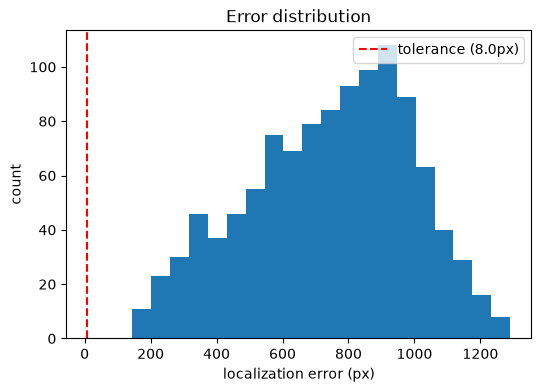

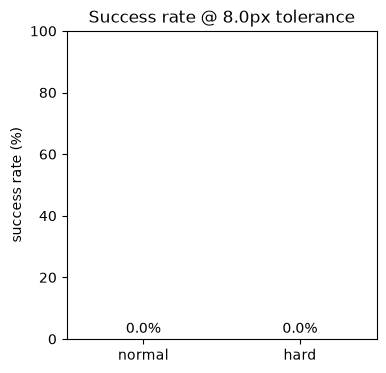

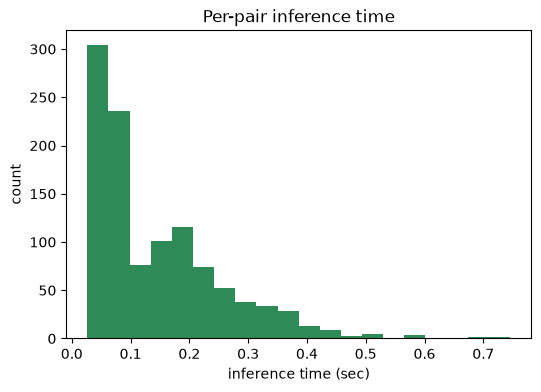

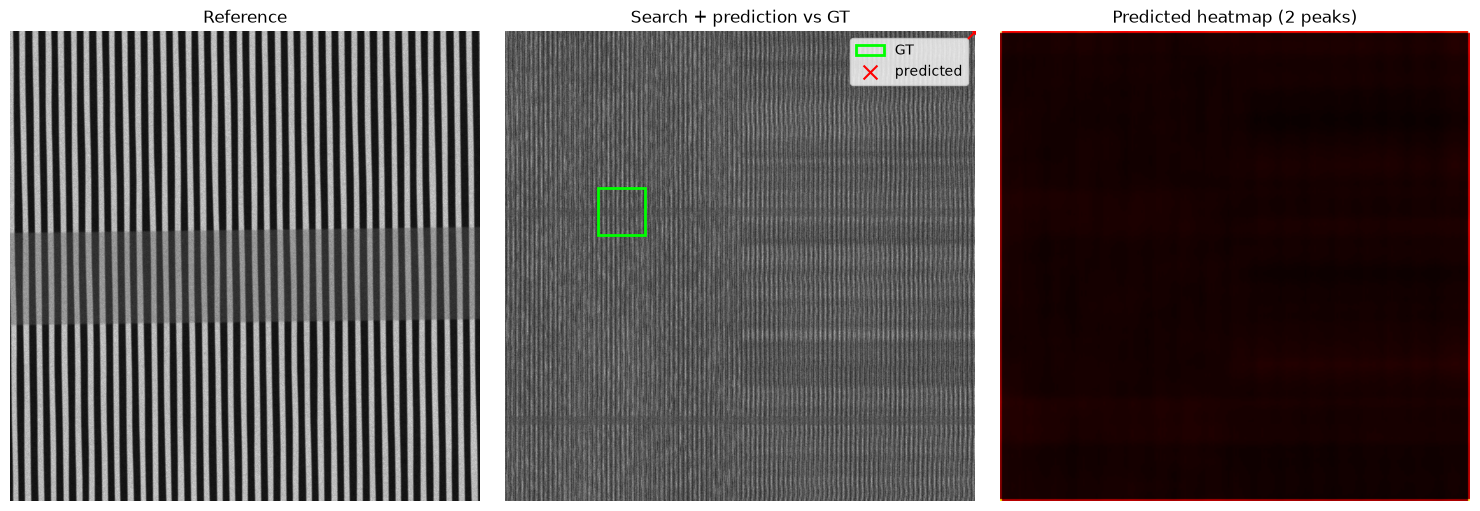

summary: n=1100  mean_err=742.63px  median_err=768.86px  success@8.0px=0.0%  mean_time=146.7ms


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import cv2, json, os, time

# ---- Load the trained checkpoint ----
device = torch.device("cuda")
model = Death().to(device)
model.load_state_dict(torch.load("driftsense_best.pt", map_location=device))
model.eval()

STRIDE = 4

def to_tensor(img):
    img = img.astype(np.float32)
    img = (img - img.mean()) / (img.std() + 1e-6)
    return torch.from_numpy(img).unsqueeze(0).unsqueeze(0)

def find_local_maxima(hm, rel_thresh=0.85):
    t = torch.from_numpy(hm).unsqueeze(0).unsqueeze(0)
    pooled = F.max_pool2d(t, kernel_size=3, stride=1, padding=1)
    keep = (t == pooled).squeeze().numpy()
    peak_val = hm.max()
    ys, xs = np.where(keep & (hm > rel_thresh * peak_val))
    return [(int(y), int(x), float(hm[y, x])) for y, x in zip(ys, xs)]

def localize(ref_img, search_img):
    ref_small = cv2.resize(ref_img, (100, 100), interpolation=cv2.INTER_AREA)
    ref_t = to_tensor(ref_small).to(device)
    search_t = to_tensor(search_img).to(device)
    with torch.no_grad():
        heatmap, offset = model(ref_t, search_t)
    hm = heatmap[0, 0].cpu().numpy()
    off = offset[0].cpu().numpy()
    candidates = find_local_maxima(hm)
    h, w = search_img.shape
    center = np.array([w/2, h/2])
    best, best_d = None, None
    for (cy, cx, score) in candidates:
        dx, dy = off[0, cy, cx], off[1, cy, cx]
        x, y = (cx+dx)*STRIDE, (cy+dy)*STRIDE
        d = np.hypot(x-center[0], y-center[1])
        if best is None or d < best_d:
            best, best_d = (x, y, score), d
    return best[0], best[1], best[2], len(candidates), hm

# ---- Point this at a HELD-OUT set, not the training folder, for real numbers ----
# If you don't have one yet, generate it first:
#   python generate_dataset.py --architecture finfet --num-pairs 30 --num-hard-cases 10 --output-dir data/test --seed 99
test_dir = "output"  # <-- swap to "data/test" once you have a proper held-out set

with open(os.path.join(test_dir, "ground_truth.json")) as f:
    records = json.load(f)

results = []
for rec in records:
    pid = rec["pair_id"]
    ref = cv2.imread(os.path.join(test_dir, "reference", f"pair_{pid:04d}_ref.png"), cv2.IMREAD_GRAYSCALE)
    search = cv2.imread(os.path.join(test_dir, "search", f"pair_{pid:04d}_search.png"), cv2.IMREAD_GRAYSCALE)
    t0 = time.perf_counter()
    x, y, score, n_cand, hm = localize(ref, search)
    dt = time.perf_counter() - t0
    err = float(np.hypot(x - rec["center_x_wide_px"], y - rec["center_y_wide_px"]))
    results.append(dict(pair_id=pid, error_px=err, time_sec=dt,
                         hard_case=rec.get("hard_case", False), n_peaks=n_cand))

errs = np.array([r["error_px"] for r in results])
times = np.array([r["time_sec"] for r in results])
hard_mask = np.array([r["hard_case"] for r in results])
TOL = 8.0

# ---- Error histogram ----
plt.figure(figsize=(6,4))
plt.hist(errs, bins=20)
plt.axvline(TOL, color="red", linestyle="--", label=f"tolerance ({TOL}px)")
plt.xlabel("localization error (px)"); plt.ylabel("count")
plt.title("Error distribution"); plt.legend()
plt.show()

# ---- Success rate: normal vs hard cases ----
normal_sr = np.mean(errs[~hard_mask] <= TOL) * 100 if (~hard_mask).any() else 0
hard_sr = np.mean(errs[hard_mask] <= TOL) * 100 if hard_mask.any() else 0
plt.figure(figsize=(4,4))
plt.bar(["normal", "hard"], [normal_sr, hard_sr], color=["steelblue", "indianred"])
plt.ylabel("success rate (%)"); plt.ylim(0, 100)
plt.title(f"Success rate @ {TOL}px tolerance")
for i, v in enumerate([normal_sr, hard_sr]):
    plt.text(i, v+2, f"{v:.1f}%", ha="center")
plt.show()

# ---- Inference time distribution ----
plt.figure(figsize=(6,4))
plt.hist(times, bins=20, color="seagreen")
plt.xlabel("inference time (sec)"); plt.ylabel("count")
plt.title("Per-pair inference time")
plt.show()

# ---- Visual sanity check: predicted point vs GT box + heatmap ----
rec = records[0]
pid = rec["pair_id"]
ref = cv2.imread(os.path.join(test_dir, "reference", f"pair_{pid:04d}_ref.png"), cv2.IMREAD_GRAYSCALE)
search = cv2.imread(os.path.join(test_dir, "search", f"pair_{pid:04d}_search.png"), cv2.IMREAD_GRAYSCALE)
x, y, score, n_cand, hm = localize(ref, search)

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(ref, cmap="gray"); axs[0].set_title("Reference"); axs[0].axis("off")

axs[1].imshow(search, cmap="gray"); axs[1].set_title("Search + prediction vs GT")
gx0, gy0, gx1, gy1 = rec["bbox_wide_px"]
axs[1].add_patch(plt.Rectangle((gx0, gy0), gx1-gx0, gy1-gy0, edgecolor="lime", facecolor="none", lw=2, label="GT"))
axs[1].scatter([x], [y], c="red", marker="x", s=100, label="predicted")
axs[1].legend(); axs[1].axis("off")

axs[2].imshow(hm, cmap="hot"); axs[2].set_title(f"Predicted heatmap ({n_cand} peaks)")
axs[2].axis("off")
plt.tight_layout(); plt.show()

print(f"summary: n={len(results)}  mean_err={errs.mean():.2f}px  median_err={np.median(errs):.2f}px  "
      f"success@{TOL}px={100*np.mean(errs<=TOL):.1f}%  mean_time={times.mean()*1000:.1f}ms")

In [ ]:
import torch
import torch.nn.functional as F

# ---- Sanity check: can the model overfit a TINY subset? ----
device = torch.device("cuda")

tiny_ds = inference.WinspPairDataset("output")
subset_idx = list(range(5))  # just 5 examples
subset = torch.utils.data.Subset(tiny_ds, subset_idx)
tiny_dl = DataLoader(subset, batch_size=5, shuffle=True)

model = Death().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(300):
    model.train()
    for batch in tiny_dl:
        ref, search = batch["reference"].to(device), batch["search"].to(device)
        hm_t, off_t, off_m = batch["heatmap"].to(device), batch["offset"].to(device), batch["offset_mask"].to(device)
        hm_p, off_p = model(ref, search)
        loss_hm = focal_loss(hm_p, hm_t, off_m)
        loss_off = (torch.abs(off_p - off_t) * off_m).sum() / off_m.sum().clamp(min=1)
        loss = loss_hm + loss_off
        opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 20 == 0:
        print(f"epoch {epoch}  loss={loss.item():.4f}")

# Now check predictions on those SAME 5 examples
model.eval()
for i in subset_idx:
    rec = tiny_ds.records[i]
    pid = rec["pair_id"]
    ref = cv2.imread(f"output/reference/pair_{pid:04d}_ref.png", cv2.IMREAD_GRAYSCALE)
    search = cv2.imread(f"output/search/pair_{pid:04d}_search.png", cv2.IMREAD_GRAYSCALE)
    x, y, score, n_cand, hm = localize(ref, search)
    gt_x, gt_y = rec["center_x_wide_px"], rec["center_y_wide_px"]
    err = ((x-gt_x)**2 + (y-gt_y)**2) ** 0.5
    print(f"pair {pid}: pred=({x:.1f},{y:.1f}) gt=({gt_x:.1f},{gt_y:.1f}) err={err:.1f}px heatmap_max={hm.max():.4f}")